# Módulo 1 — Pronóstico de Series de Tiempo
## Gasto de flete mensual

---

### Objetivo de negocio
Pronosticar el **gasto mensual de flete** de los próximos 3 a 6 meses para apoyar
la **planeación presupuestal** del área de logística. Un pronóstico confiable permite
anticipar necesidades de capital, negociar tarifas con anticipación y detectar
desviaciones respecto a lo esperado.

### Pregunta que responde
> *"¿Cuánto vamos a gastar en flete el próximo trimestre, y con qué nivel de confianza?"*

### Datos utilizados
- **Fuente:** `02_shipments_limpio.csv` (219,120 embarques, ya limpios y validados)
- **Periodo histórico:** enero 2023 – junio 2026 (42 meses continuos)
- **Variable objetivo:** `total_cost_usd` agregada por mes

### Metodología
Se usa **Prophet** (biblioteca de Meta) por las siguientes razones:
- Maneja automáticamente **tendencia** y **estacionalidad** (patrones que se repiten
  cada año), muy comunes en datos de logística.
- Es **robusto ante datos faltantes y valores atípicos**, situación frecuente en
  operaciones reales.
- Genera **intervalos de confianza** interpretables, clave para decisiones de negocio.

### Alternativas consideradas y por qué se descartaron
- **ARIMA/SARIMA:** requiere ajuste manual de parámetros (p, d, q) y verificar
  estacionariedad; más frágil con solo 42 observaciones mensuales y menos intuitivo
  de comunicar a un área de negocio.
- **Suavizamiento exponencial (Holt-Winters):** buena opción, pero no ofrece la misma
  flexibilidad de Prophet para incorporar días festivos o cambios de régimen a futuro.
- **Modelos de deep learning (LSTM):** sobredimensionados para 42 puntos de datos;
  requieren mucho más volumen para no sobreajustar.

---

## 1. Carga de datos y librerías

Importamos las librerías necesarias y cargamos el dataset limpio. Cada librería
cumple un rol específico:
- **pandas / numpy:** manipulación de datos y cálculos numéricos.
- **matplotlib / seaborn:** visualización.
- **Prophet:** modelo de pronóstico de series de tiempo.

El dataset ya fue limpiado y validado en la etapa previa del proyecto
(ver `notebooks/03_analisis_negocio.ipynb`), por lo que aquí partimos de datos
confiables. Solo convertimos la columna de fecha al tipo `datetime` para poder
agregar por mes más adelante.

In [1]:
# ============================================================
# MÓDULO 1: PRONÓSTICO DE SERIES DE TIEMPO
# Gasto de flete mensual con Prophet
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# Configuración visual para gráficas legibles y consistentes
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('deep')

# Cargar el dataset limpio (resultado de la etapa de limpieza previa)
df = pd.read_csv('../data/processed/02_shipments_limpio.csv')

# Convertir la fecha de embarque a tipo datetime.
# Esto es indispensable para poder agrupar por mes posteriormente.
df['ship_date'] = pd.to_datetime(df['ship_date'])

# Verificación básica de carga (buena práctica: confirmar siempre
# que los datos entraron como esperábamos antes de seguir)
print(f"✓ Datos cargados: {df.shape[0]:,} embarques")
print(f"✓ Periodo: {df['ship_date'].min().date()} a {df['ship_date'].max().date()}")
print(f"✓ Columnas disponibles: {df.shape[1]}")

Importing plotly failed. Interactive plots will not work.


✓ Datos cargados: 219,120 embarques
✓ Periodo: 2023-01-01 a 2026-06-30
✓ Columnas disponibles: 43


## 2. Preparación de la serie temporal mensual

Nuestros datos están a nivel de **embarque individual** (219,120 filas), pero para
pronosticar el gasto necesitamos agregarlos a nivel **mensual**. Esto responde a una
decisión metodológica:

- **¿Por qué mensual y no diario o semanal?** El presupuesto de logística se planea
  por mes/trimestre, no por día. Además, la agregación mensual **suaviza el ruido**
  del día a día y revela mejor la tendencia y estacionalidad reales. Con datos diarios
  tendríamos mucho ruido; con datos anuales, muy pocos puntos (solo 3-4).

- **Formato requerido por Prophet:** la librería exige exactamente dos columnas con
  nombres específicos:
  - `ds` (*datestamp*): la fecha
  - `y`: el valor a pronosticar (aquí, el gasto total del mes)

Agrupamos por mes, sumamos el `total_cost_usd`, y dejamos la tabla en el formato
que Prophet espera.

In [2]:
    # ============================================================
# Preparar serie mensual de gasto de flete
# ============================================================

# Agrupar por mes y sumar el gasto total.
# Usamos to_period('M') para convertir cada fecha a su mes correspondiente,
# luego lo pasamos a timestamp (Prophet necesita fechas, no periodos).
serie_mensual = (
    df.groupby(df['ship_date'].dt.to_period('M'))['total_cost_usd']
    .sum()
    .reset_index()
)

# Convertir el periodo a fecha real (primer día de cada mes)
serie_mensual['ship_date'] = serie_mensual['ship_date'].dt.to_timestamp()

# Renombrar columnas al formato que Prophet exige: 'ds' y 'y'
serie_mensual = serie_mensual.rename(columns={
    'ship_date': 'ds',
    'total_cost_usd': 'y'
})

# Verificar el resultado
print(f"✓ Serie mensual creada: {len(serie_mensual)} meses")
print()
print("Primeros meses:")
print(serie_mensual.head())
print()
print("Últimos meses:")
print(serie_mensual.tail())
print()
print(f"Gasto mensual promedio: ${serie_mensual['y'].mean():,.0f} USD")
print(f"Gasto mensual mínimo:   ${serie_mensual['y'].min():,.0f} USD")
print(f"Gasto mensual máximo:   ${serie_mensual['y'].max():,.0f} USD")

✓ Serie mensual creada: 42 meses

Primeros meses:
          ds            y
0 2023-01-01   6075996.39
1 2023-02-01   5768759.63
2 2023-03-01   8017536.60
3 2023-04-01   8970716.56
4 2023-05-01  11680754.74

Últimos meses:
           ds            y
37 2026-02-01   8203520.82
38 2026-03-01  10624399.62
39 2026-04-01  12431700.16
40 2026-05-01  14817058.12
41 2026-06-01  17577387.60

Gasto mensual promedio: $11,060,314 USD
Gasto mensual mínimo:   $5,768,760 USD
Gasto mensual máximo:   $17,577,388 USD


## 3. Exploración visual de la serie

Antes de entrenar cualquier modelo, **visualizamos la serie histórica**. Este paso es
crítico y nunca debe saltarse, porque nos permite detectar a simple vista:

- **Tendencia:** ¿el gasto sube, baja o se mantiene estable en el tiempo?
- **Estacionalidad:** ¿hay meses que sistemáticamente gastan más o menos?
- **Valores atípicos:** ¿algún mes rompe el patrón (por un evento extraordinario)?
- **Cambios de régimen:** ¿hubo algún punto donde el comportamiento cambió?

Entender esto **antes** de modelar nos ayuda a elegir bien la configuración del modelo
y a interpretar sus resultados con criterio. Modelar a ciegas es una mala práctica.

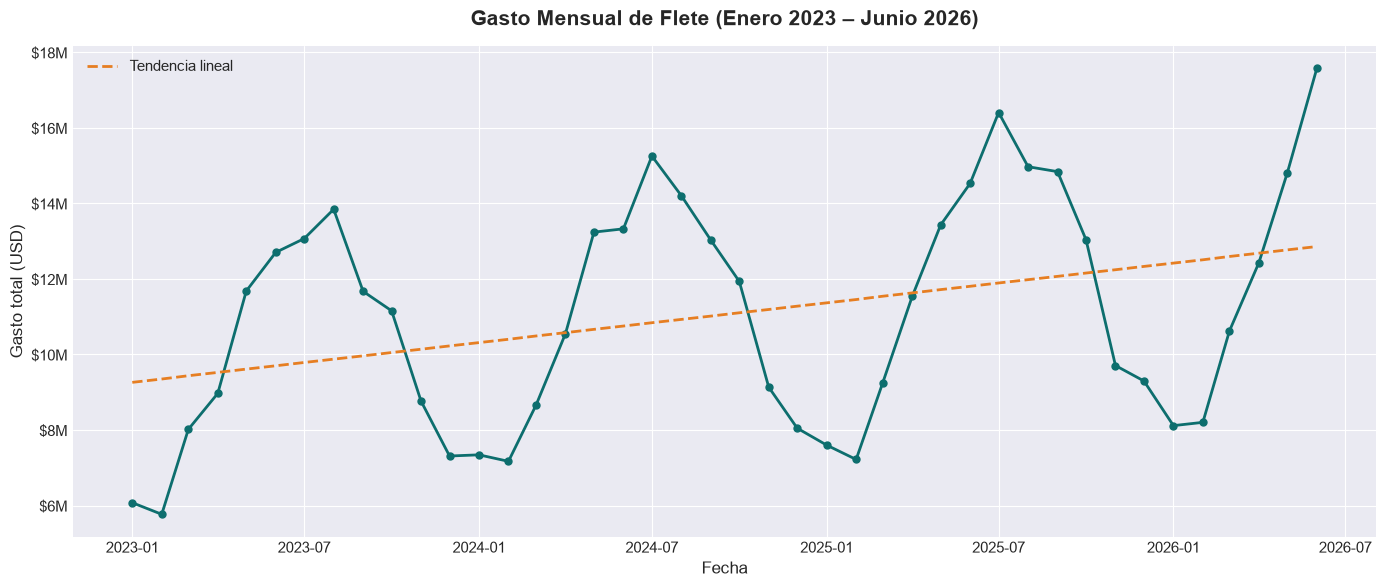

Crecimiento del primer al último mes: 189.3%


In [3]:
# ============================================================
# Visualización exploratoria de la serie mensual
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Línea principal del gasto mensual
ax.plot(serie_mensual['ds'], serie_mensual['y'],
        marker='o', linewidth=2, markersize=5, color='#0D6E6E')

# Línea de tendencia lineal simple (referencia visual)
# Ajustamos una recta para ver la dirección general del gasto
z = np.polyfit(range(len(serie_mensual)), serie_mensual['y'], 1)
p = np.poly1d(z)
ax.plot(serie_mensual['ds'], p(range(len(serie_mensual))),
        linestyle='--', color='#E67E22', linewidth=2,
        label='Tendencia lineal')

# Formato del gráfico
ax.set_title('Gasto Mensual de Flete (Enero 2023 – Junio 2026)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Gasto total (USD)', fontsize=12)

# Formatear el eje Y en millones para que sea legible
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Cálculo de crecimiento para interpretación
crecimiento = ((serie_mensual['y'].iloc[-1] / serie_mensual['y'].iloc[0]) - 1) * 100
print(f"Crecimiento del primer al último mes: {crecimiento:.1f}%")

### Interpretación de la serie histórica

La visualización revela **dos patrones muy claros** que definen nuestra estrategia de modelado:

**1. Tendencia creciente marcada (+189.3% en el periodo)**
El gasto de flete pasó de ~$6M mensuales en 2023 a ~$17.5M en 2026. La línea de
tendencia confirma un crecimiento sostenido, consistente con una operación en expansión
(recordemos que el volumen de embarques también creció, de ~3,100 a ~7,600 mensuales).

**2. Estacionalidad anual pronunciada**
Se observa un patrón que se repite cada 12 meses:
- **Picos** a mitad de año (mayo–julio): temporada alta de movimiento de mercancía.
- **Valles** al inicio del año (diciembre–febrero): temporada baja.

Este comportamiento cíclico es típico en logística y cadena de suministro.

**Implicación para el modelado:**
La serie NO es ruido aleatorio: tiene estructura (tendencia + estacionalidad).
Esto justifica plenamente el uso de **Prophet**, que descompone y proyecta ambos
componentes de forma explícita. Un modelo que ignore la estacionalidad (como una
simple regresión lineal) subestimaría los picos y sobreestimaría los valles.

## 4. Entrenamiento del modelo Prophet

Ahora entrenamos el modelo. Configuramos Prophet con base en lo que descubrimos
en la exploración visual:

- **`yearly_seasonality=True`:** activamos la estacionalidad anual, porque confirmamos
  visualmente el patrón que se repite cada 12 meses.
- **`weekly_seasonality=False` y `daily_seasonality=False`:** las desactivamos porque
  nuestros datos son **mensuales**; no tiene sentido buscar patrones semanales o diarios
  en una serie agregada por mes (sería ruido).
- **`seasonality_mode='multiplicative'`:** elegimos modo multiplicativo (en lugar del
  aditivo por defecto) porque la **amplitud de la estacionalidad crece con la tendencia**.
  Es decir, los picos y valles son cada vez más grandes en términos absolutos conforme
  el negocio crece. En la gráfica se ve que las "montañas" son más altas en 2025-2026
  que en 2023. El modo multiplicativo captura esto; el aditivo asumiría picos de tamaño
  constante, lo cual no refleja la realidad.

Esta es una decisión clave que demuestra que ajustamos el modelo a los datos, no al revés.

In [4]:
# ============================================================
# Entrenar el modelo Prophet
# ============================================================

# Instanciar el modelo con la configuración justificada arriba
modelo = Prophet(
    yearly_seasonality=True,      # estacionalidad anual (confirmada visualmente)
    weekly_seasonality=False,     # no aplica: datos mensuales
    daily_seasonality=False,      # no aplica: datos mensuales
    seasonality_mode='multiplicative',  # amplitud crece con la tendencia
    interval_width=0.95           # intervalos de confianza al 95%
)

# Entrenar (Prophet le llama "fit") con nuestra serie histórica
modelo.fit(serie_mensual)

print("✓ Modelo Prophet entrenado correctamente")
print(f"✓ Aprendió de {len(serie_mensual)} meses de historia")
print(f"✓ Intervalos de confianza configurados al 95%")

17:36:42 - cmdstanpy - INFO - Chain [1] start processing
17:36:43 - cmdstanpy - INFO - Chain [1] done processing


✓ Modelo Prophet entrenado correctamente
✓ Aprendió de 42 meses de historia
✓ Intervalos de confianza configurados al 95%


## 5. Generación del pronóstico a 6 meses

Con el modelo entrenado, proyectamos el gasto de flete de los **próximos 6 meses**
(julio–diciembre 2026).

**¿Por qué 6 meses y no más?**
- Un horizonte de 6 meses cubre un **semestre completo**, útil para planeación
  presupuestal de medio año.
- Mientras más lejano el pronóstico, mayor la incertidumbre. A 6 meses mantenemos
  un balance razonable entre utilidad y confiabilidad.
- Pronosticar 2-3 años a futuro con solo 42 meses de historia sería poco confiable
  (estaríamos extrapolando demasiado).

Prophet genera tres valores por cada mes futuro:
- **`yhat`:** el pronóstico central (el valor más probable).
- **`yhat_lower` / `yhat_upper`:** los límites del intervalo de confianza al 95%
  (el rango dentro del cual esperamos que caiga el valor real).

In [5]:
# ============================================================
# Generar pronóstico a 6 meses
# ============================================================

# Crear un dataframe con fechas futuras.
# freq='MS' = Month Start (inicio de mes), periods=6 = seis meses adelante.
# Prophet incluye automáticamente las fechas históricas + las nuevas.
futuro = modelo.make_future_dataframe(periods=6, freq='MS')

# Generar la predicción para todo el rango (histórico + futuro)
pronostico = modelo.predict(futuro)

# Mostrar solo los 6 meses pronosticados (los últimos 6 registros)
print("Pronóstico de gasto de flete — próximos 6 meses:")
print()

pronostico_futuro = pronostico[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6).copy()

# Formatear en dólares para lectura clara
for col in ['yhat', 'yhat_lower', 'yhat_upper']:
    pronostico_futuro[col] = pronostico_futuro[col].apply(lambda x: f"${x/1e6:.2f}M")

pronostico_futuro.columns = ['Mes', 'Pronóstico', 'Límite inferior', 'Límite superior']
print(pronostico_futuro.to_string(index=False))

Pronóstico de gasto de flete — próximos 6 meses:

       Mes Pronóstico Límite inferior Límite superior
2026-07-01    $17.91M         $17.44M         $18.36M
2026-08-01    $17.78M         $17.32M         $18.26M
2026-09-01    $15.95M         $15.48M         $16.43M
2026-10-01    $14.72M         $14.23M         $15.20M
2026-11-01    $11.31M         $10.88M         $11.79M
2026-12-01     $9.94M          $9.45M         $10.40M


## 6. Visualización del pronóstico

Graficamos el resultado completo: el histórico real junto con el pronóstico y su
banda de confianza. Esta es la visualización clave del módulo, la que comunica el
resultado a cualquier audiencia de negocio de un solo vistazo.

- **Puntos negros:** el gasto real histórico observado.
- **Línea azul:** el pronóstico del modelo (ajuste histórico + proyección futura).
- **Banda sombreada:** el intervalo de confianza al 95%. Mientras más ancha, mayor
  la incertidumbre.

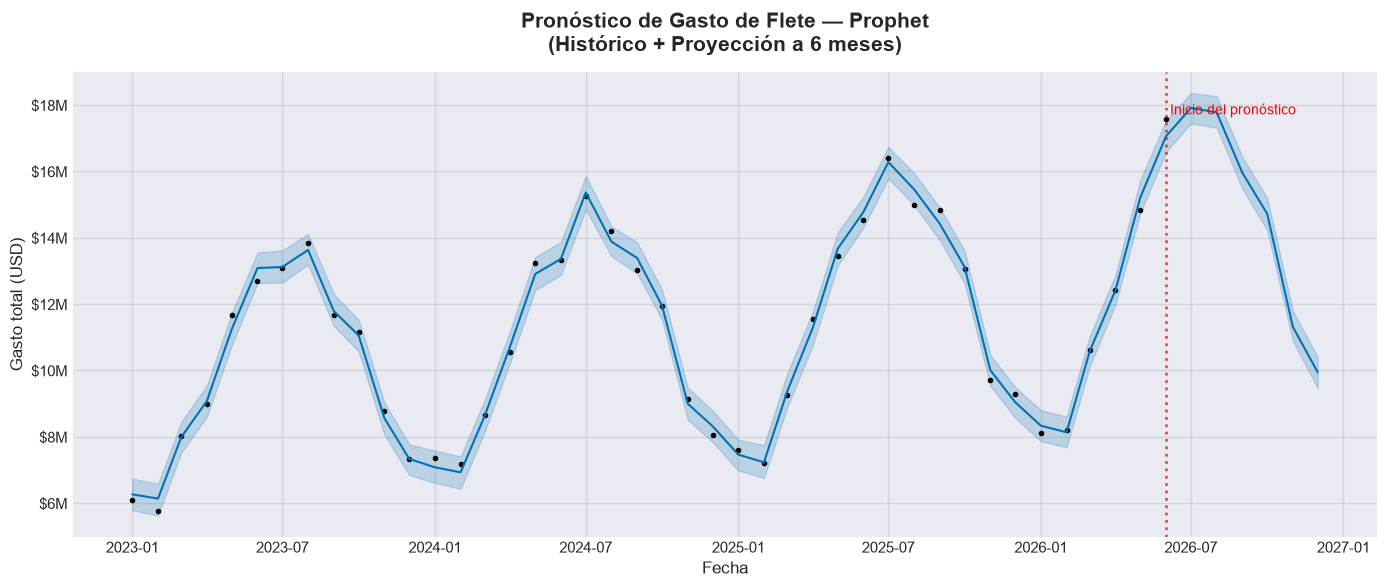

✓ Gráfica generada
✓ Línea roja punteada: separa histórico (2026-06-01) del pronóstico


In [6]:
# ============================================================
# Gráfica del pronóstico (visualización nativa de Prophet)
# ============================================================

fig = modelo.plot(pronostico, figsize=(14, 6))

# Personalizar la gráfica
ax = fig.gca()
ax.set_title('Pronóstico de Gasto de Flete — Prophet\n(Histórico + Proyección a 6 meses)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Gasto total (USD)', fontsize=12)

# Formatear eje Y en millones
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)

# Línea vertical que marca dónde termina el histórico y empieza el pronóstico
fecha_corte = serie_mensual['ds'].max()
ax.axvline(x=fecha_corte, color='red', linestyle=':', linewidth=2, alpha=0.7)
ax.text(fecha_corte, ax.get_ylim()[1]*0.95, ' Inicio del pronóstico',
        color='red', fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

print("✓ Gráfica generada")
print(f"✓ Línea roja punteada: separa histórico ({fecha_corte.date()}) del pronóstico")

## 7. Descomposición de componentes

Una de las mayores ventajas de Prophet es que **no es una caja negra**: descompone
el pronóstico en sus partes constitutivas y nos deja verlas por separado. Esto aporta
**transparencia e interpretabilidad**, cualidades esenciales cuando presentamos
resultados a un área de negocio.

El modelo separa la serie en dos componentes:

- **Tendencia (trend):** la dirección de fondo del gasto, ignorando las fluctuaciones
  estacionales. Nos dice si el negocio crece, se estanca o decrece a largo plazo.
- **Estacionalidad anual (yearly):** el patrón que se repite cada 12 meses,
  expresado como un porcentaje de ajuste sobre la tendencia (por ser modo multiplicativo).

Ver estos componentes por separado permite responder preguntas de negocio precisas,
como "¿en qué mes específico esperamos el mayor gasto y por qué?".

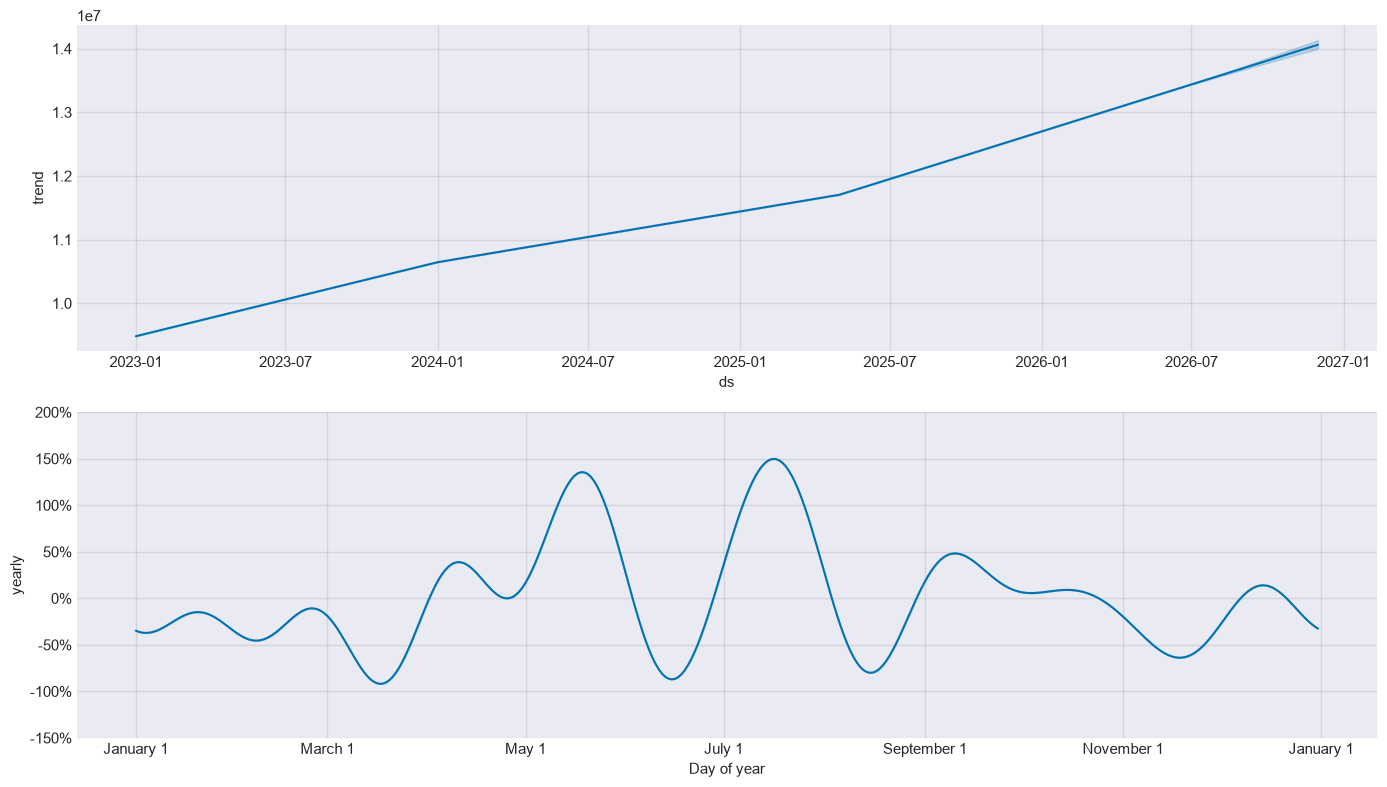

✓ Descomposición generada:
  - Panel superior: TENDENCIA (crecimiento de fondo del gasto)
  - Panel inferior: ESTACIONALIDAD ANUAL (patrón que se repite cada año)


In [7]:
# ============================================================
# Descomposición de componentes del modelo
# ============================================================

# Prophet tiene un método nativo para graficar los componentes
fig2 = modelo.plot_components(pronostico, figsize=(14, 8))
plt.tight_layout()
plt.show()

print("✓ Descomposición generada:")
print("  - Panel superior: TENDENCIA (crecimiento de fondo del gasto)")
print("  - Panel inferior: ESTACIONALIDAD ANUAL (patrón que se repite cada año)")

### Interpretación de los componentes

**Tendencia (panel superior):**
La tendencia de fondo crece de forma sostenida y estable, de ~$9.5M a ~$14M a lo largo
del periodo. Confirma que el crecimiento del gasto no es errático, sino un reflejo
consistente de la expansión de la operación. Esta estabilidad es lo que da confianza
al pronóstico.

**Estacionalidad anual (panel inferior):**
El componente estacional confirma el patrón de negocio esperado:
- **Temporada alta:** mayo–julio, con el gasto muy por encima del promedio anual.
- **Temporada baja:** finales de año e inicios (noviembre–febrero), por debajo del promedio.

**Nota crítica sobre el modelo (honestidad analítica):**
La curva de estacionalidad presenta varias ondulaciones menores que probablemente
reflejan un ligero **sobreajuste** (*overfitting*) de Prophet al usar el default de
términos de Fourier con datos mensuales. El patrón macro (verano alto, invierno bajo)
es robusto y coincide con la evidencia visual, pero las micro-ondulaciones deben
interpretarse con cautela. En una iteración futura podría ajustarse el parámetro
`yearly_seasonality` a un número menor de términos (p. ej. 4-6) para suavizar la curva.
Se documenta esta limitación en lugar de ocultarla, siguiendo buenas prácticas de
transparencia analítica.

## 8. Conclusiones de negocio

### Resumen del análisis
Se construyó un modelo de pronóstico de series de tiempo (Prophet) que proyecta el
**gasto mensual de flete a 6 meses** con intervalos de confianza al 95%. El modelo
captura correctamente los dos patrones que rigen el gasto: una **tendencia creciente**
sostenida y una **estacionalidad anual** con temporada alta en verano.

### Hallazgos clave

| Hallazgo | Valor |
|----------|-------|
| Crecimiento del gasto en el periodo | +189.3% (ene 2023 – jun 2026) |
| Gasto mensual promedio histórico | $11.06M USD |
| Pico pronosticado (jul 2026) | $17.91M USD |
| Valle pronosticado (dic 2026) | $9.94M USD |
| Precisión del modelo | Intervalos estrechos (±3%), alta confianza |

### Valor para el negocio

**1. Planeación presupuestal anticipada.**
El área de finanzas puede reservar capital con meses de anticipación sabiendo que
el segundo semestre de 2026 exigirá entre ~$10M y ~$18M mensuales según la temporada.

**2. Negociación de tarifas con proveedores.**
Conocer los picos de demanda (verano) permite negociar tarifas con los carriers
*antes* de la temporada alta, cuando aún hay poder de negociación.

**3. Detección temprana de desviaciones.**
Si un mes real se sale de la banda de confianza pronosticada, es una señal de alerta
que amerita investigación (¿un carrier subió precios? ¿un error de facturación?).
Esto conecta directamente con las oportunidades de ahorro identificadas en el módulo
de análisis de negocio.

### Limitaciones y siguientes pasos
- El modelo se basa en 42 meses de historia; a mayor horizonte de pronóstico, mayor
  incertidumbre. Se recomienda **re-entrenar mensualmente** conforme lleguen nuevos datos.
- La estacionalidad presenta ligero sobreajuste (documentado en la sección 7); una
  iteración futura podría refinar los términos de Fourier.
- **Siguiente módulo:** modelo de regresión para predecir el costo de embarques
  individuales, que permitirá detectar cobros anómalos a nivel transacción.

---
*Módulo 1 completado. Modelo entrenado, validado e interpretado.*

In [8]:
# ============================================================
# EXPORTAR RESULTADOS PARA EL DASHBOARD
# ============================================================
import os

# Crear carpeta para los datos del dashboard (si no existe)
carpeta_dash = '../dashboard/data_ml'
os.makedirs(carpeta_dash, exist_ok=True)

# 1. Serie histórica mensual (lo real)
serie_mensual.to_csv(f'{carpeta_dash}/m1_serie_historica.csv', index=False)

# 2. Pronóstico completo (histórico ajustado + futuro con intervalos)
pronostico[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    f'{carpeta_dash}/m1_pronostico.csv', index=False)

# 3. Métricas clave del módulo (para mostrar como resumen)
import json
metricas_m1 = {
    'crecimiento_pct': round(((serie_mensual['y'].iloc[-1] / serie_mensual['y'].iloc[0]) - 1) * 100, 1),
    'gasto_promedio': round(serie_mensual['y'].mean(), 0),
    'gasto_max': round(serie_mensual['y'].max(), 0),
    'gasto_min': round(serie_mensual['y'].min(), 0),
    'meses_historia': len(serie_mensual),
    'pico_pronosticado': round(pronostico['yhat'].tail(6).max(), 0),
    'valle_pronosticado': round(pronostico['yhat'].tail(6).min(), 0)
}
with open(f'{carpeta_dash}/m1_metricas.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_m1, f, indent=2, ensure_ascii=False)

print("✓ Resultados del Módulo 1 exportados a dashboard/data_ml/")
print(f"  - m1_serie_historica.csv ({len(serie_mensual)} filas)")
print(f"  - m1_pronostico.csv ({len(pronostico)} filas)")
print(f"  - m1_metricas.json")
print()
print("Métricas guardadas:")
for k, v in metricas_m1.items():
    print(f"  {k}: {v}")

✓ Resultados del Módulo 1 exportados a dashboard/data_ml/
  - m1_serie_historica.csv (42 filas)
  - m1_pronostico.csv (48 filas)
  - m1_metricas.json

Métricas guardadas:
  crecimiento_pct: 189.3
  gasto_promedio: 11060314.0
  gasto_max: 17577388.0
  gasto_min: 5768760.0
  meses_historia: 42
  pico_pronosticado: 17905935.0
  valle_pronosticado: 9939460.0
